In [ ]:
# siamese_mnist_geom_gray.py
# A JAX/Flax training script:
# - MNIST pair generator with geometric transforms (rot k*90°, optional mirror)
#   plus gray-level affine I' = a I + b
# - Siamese encoder; prediction head regresses 2x2 matrix M and scalars (a,b).
# - Loss: Frobenius norm on M + L2 on (a,b).

import math
import os
import numpy as np
import time
from typing import Tuple, Dict, Any
from collections import defaultdict

import functools
import jax
from jax import lax
import jax.numpy as jnp
import optax
from flax import linen as nn
from flax import serialization
from flax.training import train_state, checkpoints
from jax.tree_util import tree_map, tree_flatten, tree_unflatten, tree_structure
import tensorflow as tf
import tensorflow_datasets as tfds


In [ ]:
def norm_per_image(x: jnp.ndarray, eps: float = 1e-6) -> jnp.ndarray:
    """
    Per-image standardization (zero mean, unit std) for gray-level invariance.
    x: [B,H,W] in [0,1] -> standardized [B,H,W]
    """
    m = x.mean(axis=(1, 2), keepdims=True)
    v = jnp.var(x, axis=(1, 2), keepdims=True)
    return (x - m) / jnp.sqrt(v + eps)

def prepare_example(example):
    # From TFDS dict -> (image, label)
    img = example["image"]
    img = jnp.array(img, dtype=jnp.float32) / 255.0  # 28x28x1
    img = img[...,0]  # 28x28
    return img

# ----------------------------
# Centered affine warp (general 2x2 M), bilinear sampling
# ----------------------------
def _make_centered_warper(H: int, W: int):
    """Build a function warp(x, M, t) applying an inverse affine warp
       around the image center. x:[B,H,W], M:[B,2,2], t:[B,2] -> [B,H,W]."""
    # Fixed target pixel grid (row-major)
    ys = jnp.arange(H, dtype=jnp.float32)
    xs = jnp.arange(W, dtype=jnp.float32)
    grid_y, grid_x = jnp.meshgrid(ys, xs, indexing="ij")  # [H,W]
    cy = (H - 1) * 0.5
    cx = (W - 1) * 0.5

    # Centered coordinates (x first, then y)
    coords = jnp.stack([grid_x - cx, grid_y - cy], axis=-1)  # [H,W,2]

    def _bilinear_sample(img, y, x):
        """img:[H,W], y/x:[H,W] float -> bilinear sample [H,W]."""
        H_, W_ = img.shape
        x = jnp.clip(x, 0.0, W_ - 1.0001)
        y = jnp.clip(y, 0.0, H_ - 1.0001)

        x0 = jnp.floor(x).astype(jnp.int32); x1 = jnp.clip(x0 + 1, 0, W_ - 1)
        y0 = jnp.floor(y).astype(jnp.int32); y1 = jnp.clip(y0 + 1, 0, H_ - 1)

        wx = x - x0.astype(jnp.float32)
        wy = y - y0.astype(jnp.float32)

        def gather(ix, iy):
            idx = iy * W_ + ix
            return jnp.take(img.reshape(-1), idx.reshape(-1)).reshape(img.shape)

        I00 = gather(x0, y0); I10 = gather(x1, y0)
        I01 = gather(x0, y1); I11 = gather(x1, y1)

        return ((1 - wx) * (1 - wy) * I00 +
                wx       * (1 - wy) * I10 +
                (1 - wx) * wy       * I01 +
                wx       * wy       * I11)

    def _warp_single(img, M, t):
        # Ensure types
        t = t.astype(coords.dtype)
        reg = 1e-3
        Minv = jnp.linalg.inv(M + reg * jnp.eye(2, dtype=M.dtype))
        # inverse map in centered coords: x_in_c = Minv @ (x_out_c - t)
        src_c = (coords - t[None, None, :]) @ Minv.T
        sx = src_c[..., 0] + cx
        sy = src_c[..., 1] + cy
        return _bilinear_sample(img, sy, sx)

    def warp(x, M, t):
        # x:[B,H,W], M:[B,2,2], t:[B,2]
        return jax.vmap(_warp_single, in_axes=(0, 0, 0))(x, M, t)

    # IMPORTANT: return the inner function from the factory
    return warp

# Build the 28x28 warper
warp_28 = _make_centered_warper(28, 28)

In [ ]:
# ----------------------------
# TFDS input
# ----------------------------
def get_mnist_ds(split="train", shuffle=True, repeat=True):
    ds = tfds.load("mnist", split=split, as_supervised=False)
    if shuffle:
        ds = ds.shuffle(10_000, seed=0, reshuffle_each_iteration=True)
    ds = ds.map(lambda ex: {"image": ex["image"]}, num_parallel_calls=tf.data.AUTOTUNE)
    if repeat:
        ds = ds.repeat()
    ds = ds.batch(1, drop_remainder=True).prefetch(128)  # we'll take single examples in generator
    return tfds.as_numpy(ds.unbatch())  # expose dicts like {"image": np.array}

In [ ]:
# ==== Imports ====
# ------------------------------------------------------------
# Model: compact residual U-Net (predicts residual noise)
# ------------------------------------------------------------
class ConvBlock(nn.Module):
    ch: int
    use_norm: bool = False

    @nn.compact
    def __call__(self, x):
        residual = x
        x = nn.Conv(self.ch, (3,3), padding='SAME')(x)
        if self.use_norm:
            x = nn.GroupNorm(num_groups=min(8, self.ch))(x)
        x = nn.silu(x)
        x = nn.Conv(self.ch, (3,3), padding='SAME')(x)
        if self.use_norm:
            x = nn.GroupNorm(num_groups=min(8, self.ch))(x)
        x = nn.silu(x)
        # If channels differ, project residual
        if residual.shape[-1] != x.shape[-1]:
            residual = nn.Conv(self.ch, (1,1), padding='SAME')(residual)
        return x + residual

class UNetSmall(nn.Module):
    """Residual U-Net for 28x28x1 inputs; outputs residual noise (same shape)."""
    base: int = 32
    use_norm: bool = False

    @nn.compact
    def __call__(self, x):  # x: [B,28,28,1]
        # Encoder
        e1 = ConvBlock(self.base, self.use_norm)(x)            # [B,28,28,32]
        x  = nn.Conv(self.base, (3,3), strides=(2,2), padding='SAME')(e1)  # down -> 14x14
        e2 = ConvBlock(self.base*2, self.use_norm)(x)          # [B,14,14,64]
        x  = nn.Conv(self.base*2, (3,3), strides=(2,2), padding='SAME')(e2) # down -> 7x7
        # Bottleneck
        b  = ConvBlock(self.base*4, self.use_norm)(x)          # [B,7,7,128]
        # Decoder
        x  = jax.image.resize(b, (b.shape[0], 14, 14, b.shape[-1]), method='nearest')
        x  = nn.Conv(self.base*2, (3,3), padding='SAME')(x)
        x  = jnp.concatenate([x, e2], axis=-1)
        x  = ConvBlock(self.base*2, self.use_norm)(x)
        x  = jax.image.resize(x, (x.shape[0], 28, 28, x.shape[-1]), method='nearest')
        x  = nn.Conv(self.base, (3,3), padding='SAME')(x)
        x  = jnp.concatenate([x, e1], axis=-1)
        x  = ConvBlock(self.base, self.use_norm)(x)
        # Head: linear to 1 ch (residual)
        out = nn.Conv(1, (1,1), padding='SAME')(x)
        return out  # residual noise \hat{eta}

# ------------------------------------------------------------
# Noise & augmentation utilities (no salt & pepper)
# ------------------------------------------------------------
def add_gaussian_noise(key, x, sigma_max=0.25):
    """x in [0,1], shape [B,H,W]; sigma ~ U(0, sigma_max) per-batch."""
    B = x.shape[0]
    key, k_sigma, k_noise = jax.random.split(key, 3)
    sigma = jax.random.uniform(k_sigma, (B,1,1), minval=0.0, maxval=sigma_max)
    noise = jax.random.normal(k_noise, x.shape) * sigma
    return x + noise, key

def random_brightness_contrast(key, x, a_range=(0.8,1.2), b_range=(-0.1,0.1)):
    """Per-batch brightness/contrast: x -> a*x + b."""
    B = x.shape[0]
    key, k_a, k_b = jax.random.split(key, 3)
    a = jax.random.uniform(k_a, (B,1,1), minval=a_range[0], maxval=a_range[1])
    b = jax.random.uniform(k_b, (B,1,1), minval=b_range[0], maxval=b_range[1])
    y = a * x + b
    return y, key

def sample_affine_mats(key, B, rot_deg=15.0, scale_range=(0.9,1.1), shift_px=2.0):
    """Return M:[B,2,2], t:[B,2] for small centered affine transforms."""
    key, k_r, k_s, k_tx, k_ty = jax.random.split(key, 5)
    theta = jax.random.uniform(k_r, (B,), minval=-rot_deg, maxval=rot_deg) * (jnp.pi/180.0)
    c, s = jnp.cos(theta), jnp.sin(theta)
    # scales (isotropic for simplicity)
    scale = jax.random.uniform(k_s, (B,), minval=scale_range[0], maxval=scale_range[1])
    # rotations then scale
    M = jnp.stack([jnp.stack([scale*c, -scale*s], axis=-1),
                   jnp.stack([scale*s,  scale*c], axis=-1)], axis=1)  # [B,2,2]
    tx = jax.random.uniform(k_tx, (B,), minval=-shift_px, maxval=shift_px)
    ty = jax.random.uniform(k_ty, (B,), minval=-shift_px, maxval=shift_px)
    t = jnp.stack([tx, ty], axis=-1)  # [B,2]
    return M.astype(jnp.float32), t.astype(jnp.float32), key

# ------------------------------------------------------------
# Data iterator (uses your TFDS helpers & noise model)
# ------------------------------------------------------------
def make_data_iter(batch_size=256, split="train"):
    """Python generator yielding (clean, noisy) as float32 in [0,1], shapes [B,28,28]."""
    ds = get_mnist_ds(split=split, shuffle=(split=="train"), repeat=True)
    # turn ds into a simple Python iterator of clean images
    def clean_stream():
        for ex in ds:
            yield prepare_example(ex)  # [28,28] float32 in [0,1]
    stream = clean_stream()

    rng = np.random.RandomState(0)
    while True:
        # collect B clean
        x_clean = np.stack([next(stream) for _ in range(batch_size)], axis=0)  # [B,28,28]
        # simple stochastic noise mix: Gaussian then contrast/brightness (random order)
        # We'll use numpy here for determinism; JAX RNG is used in train_step anyway.
        # Apply Gaussian
        sigma = rng.uniform(1.0, 2.0)
        noisy = x_clean + rng.randn(*x_clean.shape) * sigma
        # Contrast/brightness
        a = rng.uniform(0.8, 1.2); b = rng.uniform(-0.1, 0.1)
        noisy = (a*noisy + b).astype(np.float32)
        yield x_clean.astype(np.float32), noisy

# ------------------------------------------------------------
# Losses: Charbonnier, global-SSIM, TV, Equivariance
# ------------------------------------------------------------
def charbonnier_loss(x_hat, x, eps=1e-3):
    """x_hat, x: [B,H,W] in [0,1] (or standardized)"""
    diff = x_hat - x
    return jnp.mean(jnp.sqrt(diff*diff + eps*eps))

def ssim_global(x, y, c1=0.01**2, c2=0.03**2):
    """Global SSIM (single-channel), per-image then mean over batch."""
    # x,y: [B,H,W], not necessarily [0,1] if standardized
    B = x.shape[0]
    x_mu = jnp.mean(x, axis=(1,2), keepdims=True)
    y_mu = jnp.mean(y, axis=(1,2), keepdims=True)
    x_var = jnp.mean((x - x_mu)**2, axis=(1,2), keepdims=True)
    y_var = jnp.mean((y - y_mu)**2, axis=(1,2), keepdims=True)
    xy_cov = jnp.mean((x - x_mu)*(y - y_mu), axis=(1,2), keepdims=True)

    num = (2*x_mu*y_mu + c1)*(2*xy_cov + c2)
    den = (x_mu**2 + y_mu**2 + c1)*(x_var + y_var + c2)
    ssim = (num / den).reshape(B)
    return 1.0 - jnp.mean(ssim)  # as a loss

def tv_loss(x):
    """Isotropic TV: x [B,H,W]."""
    dx = jnp.abs(x[:, :, 1:] - x[:, :, :-1])
    dy = jnp.abs(x[:, 1:, :] - x[:, :-1, :])
    return (jnp.mean(dx) + jnp.mean(dy))

def equivariance_loss(x_noisy, f_apply, params, rng_key):
    """Denoise x_noisy, apply random affine; enforce warp(denoise(aug)) ~ denoise(orig).
       Uses global L1 on [B,H,W] (standardized inside)."""
    B, H, W = x_noisy.shape
    # denoise originals
    x_in  = x_noisy[..., None]  # [B,H,W,1]
    eta   = f_apply({'params': params}, x_in)
    xhat  = x_noisy - eta[...,0]

    # sample affine and apply to noisy
    M, t, rng_key = sample_affine_mats(rng_key, B)
    x_noisy_prime = warp_28(x_noisy, M, t)  # [B,H,W]
    eta_p = f_apply({'params': params}, x_noisy_prime[...,None])
    xhat_p = x_noisy_prime - eta_p[...,0]

    # compare warp(xhat_p) to xhat
    xhat_p_warp = warp_28(xhat_p, M, t)

    # standardize inside the loss
    a = norm_per_image(xhat)
    b = norm_per_image(xhat_p_warp)
    return jnp.mean(jnp.abs(a - b))

# ------------------------------------------------------------
# Create TrainState (AdamW + warmup-cosine) + EMA
# ------------------------------------------------------------
class TrainState(train_state.TrainState):
    ema_params: Any

def create_train_state(rng, lr=1e-3, wd=1e-4, warmup_steps=100, total_steps=50_000,
                       base_ch=32, use_norm=False):
    model = UNetSmall(base=base_ch, use_norm=use_norm)
    dummy = jnp.zeros((1,28,28,1), dtype=jnp.float32)
    params = model.init(rng, dummy)['params']

    schedule = optax.warmup_cosine_decay_schedule(
        init_value=0.0,
        peak_value=lr,
        warmup_steps=warmup_steps,
        decay_steps=max(1, total_steps - warmup_steps),
        end_value=lr*0.05,
    )
    tx = optax.chain(
        optax.add_decayed_weights(wd),
        optax.adamw(learning_rate=schedule)
    )

    state = TrainState(
        apply_fn=model.apply,
        params=params,
        tx=tx,
        opt_state=tx.init(params),
        ema_params=params,
        step=jnp.array(0)  # <- required by Flax TrainState
    )
    return state, model, schedule

def ema_update(ema_params, new_params, decay=0.999):
    return tree_map(lambda e, p: decay * e + (1.0 - decay) * p, ema_params, new_params)

# ------------------------------------------------------------
# One train step (JIT) returning updated state and metrics
# ------------------------------------------------------------
@jax.jit
def train_step(state: TrainState,
               batch: Tuple[jnp.ndarray, jnp.ndarray],
               rng_key: jax.Array,
               loss_weights: Dict[str, float]):
    x_clean, x_noisy = batch

    def loss_fn(params, rng_eq):
        res = state.apply_fn({'params': params}, x_noisy[...,None])
        x_hat = x_noisy - res[...,0]

        x_hat_n   = norm_per_image(x_hat)
        x_clean_n = norm_per_image(x_clean)

        l_rec  = charbonnier_loss(x_hat_n, x_clean_n)
        l_ssim = ssim_global(x_hat_n, x_clean_n)
        l_tv   = tv_loss(x_hat)
        l_eq   = equivariance_loss(x_noisy, state.apply_fn, params, rng_eq)

        total = (loss_weights['rec']  * l_rec +
                 loss_weights['ssim'] * l_ssim +
                 loss_weights['tv']   * l_tv +
                 loss_weights['eq']   * l_eq)
        metrics = {'loss': total, 'l_rec': l_rec, 'l_ssim': l_ssim, 'l_tv': l_tv, 'l_eq': l_eq}
        return total, metrics

    rng_key, rng_eq = jax.random.split(rng_key)
    grads, metrics = jax.grad(loss_fn, has_aux=True)(state.params, rng_eq)
    updates, new_opt_state = state.tx.update(grads, state.opt_state, state.params)
    new_params = optax.apply_updates(state.params, updates)
    new_ema    = ema_update(state.ema_params, new_params, decay=0.999)

    new_state = state.replace(
        params=new_params,
        opt_state=new_opt_state,
        ema_params=new_ema,
        step=state.step + 1          # <- increment built-in step
    )
    return new_state, metrics, rng_key

# ------------------------------------------------------------
# Convenient batch fetcher for JAX (from the Python generator)
# ------------------------------------------------------------
def next_batch(data_iter, batch_size, key=None):
    """Fetch one batch from the Python generator but also (optionally)
       re-apply JAX noise for determinism inside step loops."""
    x_clean, x_noisy = next(data_iter)  # np arrays [B,H,W]
    if key is not None:
        # Optionally re-augment with JAX (Gaussian + brightness/contrast)
        key, k1 = jax.random.split(key)
        x_noisy_j, k1 = add_gaussian_noise(k1, jnp.asarray(x_clean))
        x_noisy_j, k1 = random_brightness_contrast(k1, x_noisy_j)
        return jnp.asarray(x_clean), x_noisy_j, key
    return jnp.asarray(x_clean), jnp.asarray(x_noisy), None

# ------------------------------------------------------------
# Default loss weights (as discussed)
# ------------------------------------------------------------
DEFAULT_LOSS_WEIGHTS = dict(rec=1.0, ssim=0.1, tv=1e-3, eq=0.1)

In [ ]:
# ----------------------------
# Metrics helpers
# ----------------------------
def psnr(x_hat, x, eps=1e-8):
    """x_hat, x in [0,1], shape [B,H,W]"""
    mse = jnp.mean((x_hat - x) ** 2, axis=(1,2))
    psnr_b = 20.0 * jnp.log10(1.0) - 10.0 * jnp.log10(mse + eps)
    return jnp.mean(psnr_b)

@functools.partial(jax.jit, static_argnames=("apply_fn",))
def denoise_batch(params, apply_fn, x_noisy):
    resid = apply_fn({'params': params}, x_noisy[..., None])
    return x_noisy - resid[..., 0]

def build_eval_set(n_samples=1024, seed=123):
    """Return a fixed clean batch [N,28,28] from MNIST test split."""
    ds = get_mnist_ds(split="test", shuffle=False, repeat=False)
    clean = []
    for i, ex in enumerate(ds):
        clean.append(prepare_example(ex))
        if len(clean) >= n_samples:
            break
    clean = jnp.asarray(np.stack(clean, axis=0), dtype=jnp.float32)  # [N,28,28]
    return clean

def add_fixed_gaussian(x, sigma):
    key = jax.random.PRNGKey(int(sigma * 1e6) % (2**31-1))
    noise = jax.random.normal(key, x.shape) * sigma
    return x + noise

def eval_model(state, eval_clean, sigmas=(0.10, 0.20, 0.30), batch_size=256):
    """Evaluate EMA params on fixed clean images at given noise levels."""
    rng = jax.random.PRNGKey(0)
    results = {}
    params = state.ema_params
    N = eval_clean.shape[0]
    for sigma in sigmas:
        # corrupt
        x_noisy = add_fixed_gaussian(eval_clean, sigma)
        # batched denoise
        psnrs = []; ssim_losses = []
        for i in range(0, N, batch_size):
            xb = x_noisy[i:i+batch_size]
            xc = eval_clean[i:i+batch_size]
            xh = denoise_batch(params, state.apply_fn, xb)
            psnrs.append(psnr(xh, xc))
            # SSIM is a loss (1 - SSIM), so convert back to SSIM for reporting
            ssim_l = ssim_global(norm_per_image(xh), norm_per_image(xc))
            ssim_losses.append(ssim_l)
        psnr_mean = float(jnp.mean(jnp.stack(psnrs)))
        ssim_mean = 1.0 - float(jnp.mean(jnp.stack(ssim_losses)))
        results[f"sigma={sigma:.2f}/PSNR"] = psnr_mean
        results[f"sigma={sigma:.2f}/SSIM"] = ssim_mean
    return results

def format_metrics(step, metrics_dict):
    head = f"[step {step}] "
    parts = [f"{k}={v:.4f}" for k, v in metrics_dict.items()]
    return head + " | ".join(parts)

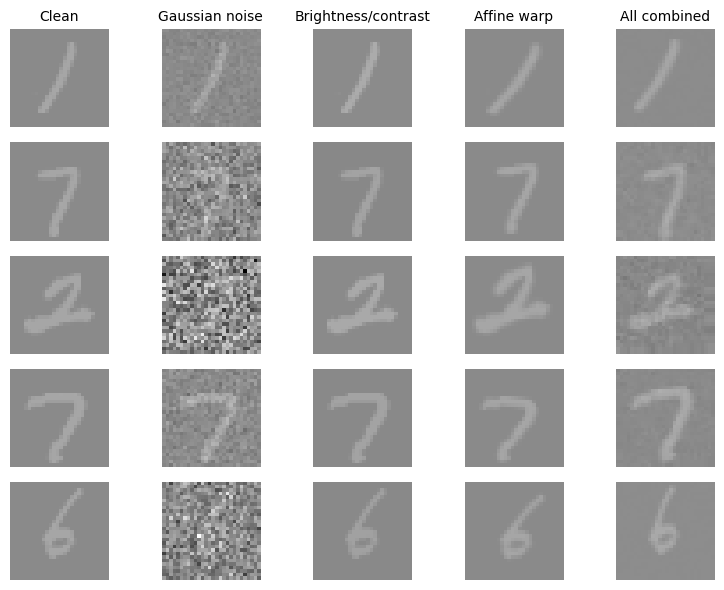

In [ ]:
import matplotlib.pyplot as plt

# -------------------------------
# Visual sanity check before training
# -------------------------------

# Get 5 clean MNIST digits
ds = get_mnist_ds(split="train", shuffle=True, repeat=False)
samples = [prepare_example(ex) for _, ex in zip(range(5), ds)]
x_clean = jnp.stack(samples, axis=0)  # [5,28,28]

# Make one copy per augmentation type
key = jax.random.PRNGKey(0)
key, k_noise, k_bc, k_aff = jax.random.split(key, 4)

# Apply Gaussian noise
x_gauss, _ = add_gaussian_noise(k_noise, x_clean, sigma_max=2)

# Apply brightness/contrast change
x_bc, _ = random_brightness_contrast(k_bc, x_clean)

# Apply random affine warp (rotation + shift)
M, t, k_aff = sample_affine_mats(k_aff, x_clean.shape[0])
x_aff = warp_28(x_clean, M, t)

# Apply *all* augmentations combined (just to see extremes)
x_all, k_all = add_gaussian_noise(k_aff, x_clean, sigma_max=0.25)
x_all, k_all = random_brightness_contrast(k_all, x_all)
M2, t2, _ = sample_affine_mats(k_all, x_clean.shape[0])
x_all = warp_28(x_all, M2, t2)

# -------------------------------
# Plot results
# -------------------------------
fig, axs = plt.subplots(5, 5, figsize=(8, 6))
titles = ["Clean", "Gaussian noise", "Brightness/contrast", "Affine warp", "All combined"]

# Fix color scale across all images (so gray levels are comparable)
vmin, vmax = np.min(x_gauss.flatten()), np.max(x_gauss.flatten())

for i in range(5):  # rows = different examples
    imgs = [x_clean[i], x_gauss[i], x_bc[i], x_aff[i], x_all[i]]
    for j, img in enumerate(imgs):
        axs[i, j].imshow(np.array(img), cmap="gray", vmin=vmin, vmax=vmax)
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j], fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# ==== Main training loop with checkpoint handling ====
def model_exists(ckpt_dir):
    """Return True if a checkpoint exists."""
    latest = checkpoints.latest_checkpoint(ckpt_dir)
    return latest is not None

def save_final_model(state, ckpt_dir, filename="final_model"):
    path = os.path.join(ckpt_dir, f"{filename}.npz")
    os.makedirs(ckpt_dir, exist_ok=True)
    flat, treedef = tree_flatten(state.ema_params)
    np.savez(path, *flat)
    print(f"✅ Final model (EMA params) saved to {path}")

def load_final_model(path, state):
    data = np.load(path)
    flat = [data[k] for k in sorted(data.files, key=lambda s: int(s.replace("arr_", "")))]
    treedef = tree_structure(state.ema_params)
    ema_params = tree_unflatten(treedef, flat)
    return state.replace(ema_params=ema_params, params=ema_params)

def train(
    *,
    total_steps=20_000,
    batch_size=256,
    eval_every=500,
    ckpt_every=2_000,
    ckpt_dir="./checkpoints_mnist_denoise",
    loss_weights=DEFAULT_LOSS_WEIGHTS,
    base_ch=32,
    use_norm=False,
    seed=0
):
    # ✅ Make checkpoint dir absolute
    ckpt_dir = os.path.abspath(ckpt_dir)
    os.makedirs(ckpt_dir, exist_ok=True)
    final_model_path = os.path.join(ckpt_dir, "final_model.npz")

    # If final model exists, load and skip training
    if os.path.exists(final_model_path):
        print(f"⚠️  Final model found at {final_model_path}. Skipping training.")
        state, model, _ = create_train_state(jax.random.PRNGKey(seed+1),
                                             base_ch=base_ch, use_norm=use_norm)
        state = load_final_model(final_model_path, state)
        print("Model loaded and ready for inference.")
        return state, model

    print("🚀 No existing model found. Starting training...")
    train_iter = make_data_iter(batch_size=batch_size, split="train")
    eval_clean = build_eval_set(n_samples=1024, seed=123)

    key = jax.random.PRNGKey(seed)
    state, model, schedule = create_train_state(
        jax.random.PRNGKey(seed+1),
        lr=1e-3, wd=1e-4, warmup_steps=1_000, total_steps=total_steps,
        base_ch=base_ch, use_norm=use_norm
    )

    # Proper restore (now absolute path)
    state = checkpoints.restore_checkpoint(ckpt_dir, target=state)
    if int(state.step) > 0:
        print(f"🔄 Resumed from checkpoint at step {int(state.step)}")

    t0 = time.time()
    running = defaultdict(float)
    window = 100
    step = int(state.step)     # <-- was step_count; use .step everywhere

    while step < total_steps:
        key, k_batch = jax.random.split(key)
        x_clean, x_noisy, _ = next_batch(train_iter, batch_size, key=k_batch)

        state, metrics, key = train_step(state, (x_clean, x_noisy), key, loss_weights)
        step = int(state.step)  # <-- update from state.step

        for k, v in metrics.items():
            running[k] = (running[k] * (window - 1) + float(v)) / window

        if step % 100 == 0 or step == 1:
            lr_now = float(schedule(step))
            log = {
                "loss": running["loss"],
                "l_rec": running["l_rec"],
                "l_ssim": running["l_ssim"],
                "l_tv": running["l_tv"],
                "l_eq": running["l_eq"],
                "lr": lr_now,
            }
            print(f"[step {step}] " + " | ".join(f"{k}={v:.4f}" for k, v in log.items()))
            t0 = time.time()

        if step % eval_every == 0 or step == total_steps:
            eval_res = eval_model(state, eval_clean, sigmas=(0.5, 1.0, 1.5, 2.0))
            print(f"[step {step}] " + " | ".join(f"{k}={v:.3f}" for k, v in eval_res.items()))

        if step % ckpt_every == 0 or step == total_steps:
            checkpoints.save_checkpoint(ckpt_dir, target=state, step=step, keep=3, overwrite=True)
            print(f"💾 Checkpoint saved at step {step}")

    # Save final EMA params
    save_final_model(state, ckpt_dir)
    print("✅ Training complete.")
    return state, model

state, model = train(
    total_steps=10_000,
    batch_size=256,
    eval_every=500,
    ckpt_every=2_000,
    base_ch=32,
    use_norm=False,
    seed=0
)


🚀 No existing model found. Starting training...
[step 1] loss=0.0045 | l_rec=0.0036 | l_ssim=0.0012 | l_tv=0.0087 | l_eq=0.0076 | lr=0.0000
[step 100] loss=0.1978 | l_rec=0.1513 | l_ssim=0.0380 | l_tv=0.7951 | l_eq=0.4196 | lr=0.0001
[step 200] loss=0.1830 | l_rec=0.1268 | l_ssim=0.0301 | l_tv=1.4501 | l_eq=0.5174 | lr=0.0002
[step 300] loss=0.1499 | l_rec=0.0920 | l_ssim=0.0211 | l_tv=1.4018 | l_eq=0.5440 | lr=0.0003
[step 400] loss=0.1315 | l_rec=0.0732 | l_ssim=0.0165 | l_tv=1.3321 | l_eq=0.5529 | lr=0.0004
[step 500] loss=0.1214 | l_rec=0.0631 | l_ssim=0.0140 | l_tv=1.2490 | l_eq=0.5558 | lr=0.0005
[step 500] sigma=0.50/PSNR=-2.353 | sigma=0.50/SSIM=0.709 | sigma=1.00/PSNR=-6.857 | sigma=1.00/SSIM=0.437 | sigma=1.50/PSNR=-9.974 | sigma=1.50/SSIM=0.297 | sigma=2.00/PSNR=-12.269 | sigma=2.00/SSIM=0.223
[step 600] loss=0.1159 | l_rec=0.0576 | l_ssim=0.0127 | l_tv=1.1135 | l_eq=0.5587 | lr=0.0006
[step 700] loss=0.1115 | l_rec=0.0536 | l_ssim=0.0117 | l_tv=0.9516 | l_eq=0.5583 | lr=0.0

[step 2000] sigma=0.50/PSNR=-3.155 | sigma=0.50/SSIM=0.889 | sigma=1.00/PSNR=-4.893 | sigma=1.00/SSIM=0.595 | sigma=1.50/PSNR=-5.310 | sigma=1.50/SSIM=0.342 | sigma=2.00/PSNR=-5.871 | sigma=2.00/SSIM=0.217
💾 Checkpoint saved at step 2000
[step 2100] loss=0.0984 | l_rec=0.0409 | l_ssim=0.0088 | l_tv=0.5456 | l_eq=0.5600 | lr=0.0010
[step 2200] loss=0.0979 | l_rec=0.0405 | l_ssim=0.0087 | l_tv=0.5328 | l_eq=0.5593 | lr=0.0009
[step 2300] loss=0.0978 | l_rec=0.0403 | l_ssim=0.0087 | l_tv=0.5210 | l_eq=0.5609 | lr=0.0009
[step 2400] loss=0.0975 | l_rec=0.0402 | l_ssim=0.0086 | l_tv=0.5092 | l_eq=0.5597 | lr=0.0009
[step 2500] loss=0.0972 | l_rec=0.0399 | l_ssim=0.0085 | l_tv=0.4982 | l_eq=0.5593 | lr=0.0009
[step 2500] sigma=0.50/PSNR=-2.177 | sigma=0.50/SSIM=0.899 | sigma=1.00/PSNR=-3.496 | sigma=1.00/SSIM=0.598 | sigma=1.50/PSNR=-3.771 | sigma=1.50/SSIM=0.352 | sigma=2.00/PSNR=-4.438 | sigma=2.00/SSIM=0.232
[step 2600] loss=0.0971 | l_rec=0.0398 | l_ssim=0.0085 | l_tv=0.4896 | l_eq=0.559

[step 4000] sigma=0.50/PSNR=1.416 | sigma=0.50/SSIM=0.898 | sigma=1.00/PSNR=-0.878 | sigma=1.00/SSIM=0.582 | sigma=1.50/PSNR=-3.065 | sigma=1.50/SSIM=0.417 | sigma=2.00/PSNR=-5.111 | sigma=2.00/SSIM=0.337
💾 Checkpoint saved at step 4000
[step 4100] loss=0.0951 | l_rec=0.0382 | l_ssim=0.0080 | l_tv=0.3775 | l_eq=0.5567 | lr=0.0007
[step 4200] loss=0.0948 | l_rec=0.0382 | l_ssim=0.0080 | l_tv=0.3716 | l_eq=0.5544 | lr=0.0007
[step 4300] loss=0.0944 | l_rec=0.0382 | l_ssim=0.0080 | l_tv=0.3675 | l_eq=0.5500 | lr=0.0007
[step 4400] loss=0.0952 | l_rec=0.0387 | l_ssim=0.0081 | l_tv=0.3641 | l_eq=0.5531 | lr=0.0006
[step 4500] loss=0.0950 | l_rec=0.0383 | l_ssim=0.0081 | l_tv=0.3607 | l_eq=0.5553 | lr=0.0006
[step 4500] sigma=0.50/PSNR=2.438 | sigma=0.50/SSIM=0.899 | sigma=1.00/PSNR=-0.235 | sigma=1.00/SSIM=0.580 | sigma=1.50/PSNR=-2.667 | sigma=1.50/SSIM=0.427 | sigma=2.00/PSNR=-4.851 | sigma=2.00/SSIM=0.351
[step 4600] loss=0.0944 | l_rec=0.0383 | l_ssim=0.0081 | l_tv=0.3548 | l_eq=0.5501 

[step 6000] sigma=0.50/PSNR=4.814 | sigma=0.50/SSIM=0.899 | sigma=1.00/PSNR=1.897 | sigma=1.00/SSIM=0.603 | sigma=1.50/PSNR=-1.112 | sigma=1.50/SSIM=0.438 | sigma=2.00/PSNR=-3.868 | sigma=2.00/SSIM=0.363
💾 Checkpoint saved at step 6000
[step 6100] loss=0.0910 | l_rec=0.0375 | l_ssim=0.0079 | l_tv=0.2968 | l_eq=0.5241 | lr=0.0003
[step 6200] loss=0.0908 | l_rec=0.0375 | l_ssim=0.0080 | l_tv=0.2932 | l_eq=0.5218 | lr=0.0003
[step 6300] loss=0.0906 | l_rec=0.0375 | l_ssim=0.0080 | l_tv=0.2894 | l_eq=0.5201 | lr=0.0003
[step 6400] loss=0.0902 | l_rec=0.0374 | l_ssim=0.0079 | l_tv=0.2853 | l_eq=0.5174 | lr=0.0003
[step 6500] loss=0.0897 | l_rec=0.0371 | l_ssim=0.0079 | l_tv=0.2821 | l_eq=0.5150 | lr=0.0003
[step 6500] sigma=0.50/PSNR=5.636 | sigma=0.50/SSIM=0.903 | sigma=1.00/PSNR=2.813 | sigma=1.00/SSIM=0.604 | sigma=1.50/PSNR=-0.038 | sigma=1.50/SSIM=0.432 | sigma=2.00/PSNR=-2.687 | sigma=2.00/SSIM=0.352
[step 6600] loss=0.0910 | l_rec=0.0372 | l_ssim=0.0078 | l_tv=0.2809 | l_eq=0.5270 | 

[step 8000] sigma=0.50/PSNR=8.412 | sigma=0.50/SSIM=0.908 | sigma=1.00/PSNR=4.986 | sigma=1.00/SSIM=0.580 | sigma=1.50/PSNR=2.001 | sigma=1.50/SSIM=0.420 | sigma=2.00/PSNR=-0.403 | sigma=2.00/SSIM=0.347
💾 Checkpoint saved at step 8000
[step 8100] loss=0.0847 | l_rec=0.0370 | l_ssim=0.0079 | l_tv=0.2311 | l_eq=0.4674 | lr=0.0001
[step 8200] loss=0.0844 | l_rec=0.0368 | l_ssim=0.0078 | l_tv=0.2292 | l_eq=0.4652 | lr=0.0001
[step 8300] loss=0.0841 | l_rec=0.0369 | l_ssim=0.0078 | l_tv=0.2273 | l_eq=0.4623 | lr=0.0001
[step 8400] loss=0.0840 | l_rec=0.0368 | l_ssim=0.0078 | l_tv=0.2258 | l_eq=0.4617 | lr=0.0001
[step 8500] loss=0.0839 | l_rec=0.0369 | l_ssim=0.0078 | l_tv=0.2243 | l_eq=0.4599 | lr=0.0001
[step 8500] sigma=0.50/PSNR=9.148 | sigma=0.50/SSIM=0.908 | sigma=1.00/PSNR=5.440 | sigma=1.00/SSIM=0.564 | sigma=1.50/PSNR=2.276 | sigma=1.50/SSIM=0.411 | sigma=2.00/PSNR=-0.146 | sigma=2.00/SSIM=0.345
[step 8600] loss=0.0838 | l_rec=0.0369 | l_ssim=0.0078 | l_tv=0.2224 | l_eq=0.4589 | lr

[step 10000] sigma=0.50/PSNR=10.785 | sigma=0.50/SSIM=0.904 | sigma=1.00/PSNR=7.716 | sigma=1.00/SSIM=0.495 | sigma=1.50/PSNR=4.819 | sigma=1.50/SSIM=0.323 | sigma=2.00/PSNR=2.731 | sigma=2.00/SSIM=0.246
💾 Checkpoint saved at step 10000
✅ Final model (EMA params) saved to /content/checkpoints_mnist_denoise/final_model.npz
✅ Training complete.


✅ Loading trained model from /content/checkpoints_mnist_denoise/final_model.npz


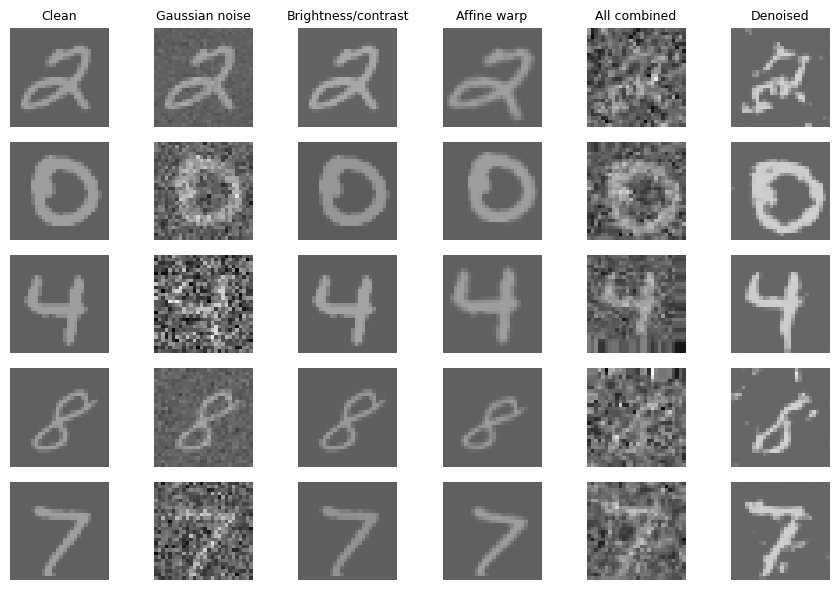

Average PSNR after denoising: 6.54 dB


In [ ]:
# -------------------------------
# 1️⃣  Load the trained model
# -------------------------------
ckpt_dir = os.path.abspath("./checkpoints_mnist_denoise")
final_model_path = os.path.join(ckpt_dir, "final_model.npz")

state, model, _ = create_train_state(jax.random.PRNGKey(0))
if os.path.exists(final_model_path):
    print(f"✅ Loading trained model from {final_model_path}")
    state = load_final_model(final_model_path, state)
else:
    print("⚠️ No trained model found — using random weights (expect nonsense denoising).")

sigma_max=1

# -------------------------------
# 2️⃣  Prepare a few clean digits
# -------------------------------
ds = get_mnist_ds(split="test", shuffle=False, repeat=False)
samples = [prepare_example(ex) for _, ex in zip(range(5), ds)]
x_clean = jnp.stack(samples, axis=0)  # [5,28,28]

# -------------------------------
# 3️⃣  Apply augmentations
# -------------------------------
key = jax.random.PRNGKey(0)
key, k_noise, k_bc, k_aff = jax.random.split(key, 4)

x_gauss, _ = add_gaussian_noise(k_noise, x_clean, sigma_max=sigma_max)
x_bc, _    = random_brightness_contrast(k_bc, x_clean)
M, t, _    = sample_affine_mats(k_aff, x_clean.shape[0])
x_aff      = warp_28(x_clean, M, t)

# Combined augmentations (the ones we'll denoise)
x_all, k_all = add_gaussian_noise(k_aff, x_clean, sigma_max=sigma_max)
x_all, k_all = random_brightness_contrast(k_all, x_all)
M2, t2, _    = sample_affine_mats(k_all, x_clean.shape[0])
x_all        = warp_28(x_all, M2, t2)

# -------------------------------
# 4️⃣  Denoise with the trained model
# -------------------------------
x_denoised = denoise_batch(state.ema_params, state.apply_fn, x_all)

# -------------------------------
# 5️⃣  Plot all versions
# -------------------------------
fig, axs = plt.subplots(5, 6, figsize=(9, 6))
titles = ["Clean", "Gaussian noise", "Brightness/contrast",
          "Affine warp", "All combined", "Denoised"]

vmin, vmax =np.min(x_all.flatten()), np.max(x_all.flatten())

for i in range(5):  # one row per digit
    imgs = [x_clean[i], x_gauss[i], x_bc[i], x_aff[i], x_all[i], x_denoised[i]]
    for j, img in enumerate(imgs):
        axs[i, j].imshow(np.array(img), cmap="gray", vmin=vmin, vmax=vmax)
        axs[i, j].axis("off")
        if i == 0:
            axs[i, j].set_title(titles[j], fontsize=9)

plt.tight_layout()
plt.show()

# -------------------------------
# 6️⃣  Quantitative check (optional)
# -------------------------------
psnr_val = float(psnr(x_denoised, x_clean))
print(f"Average PSNR after denoising: {psnr_val:.2f} dB")